# FINM3403 — China Exposure from an Australian Investor Perspective
### Parts C–G: Data Construction, Regressions, Correlations, Risk-Return & Portfolio Optimisation
---

## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10

# ── Configuration ──────────────────────────────────────────────────────
START = "2011-03-01"   # one month before April 2011 so returns start April 2011
END   = "2025-12-31"
RF    = 0.0            # risk-free rate = 0 as specified in task sheet

TICKERS_AUS = [
    "FMG.AX", "RIO.AX",   # Iron ore / mining
    "WDS.AX", "STO.AX",   # LNG / energy
    "TWE.AX", "A2M.AX",   # Agriculture / food
    "IEL.AX", "FLT.AX",   # Education / tourism
    "COH.AX", "RMD.AX",   # Healthcare
    "GMG.AX", "QUB.AX",   # Logistics / property
]

INDUSTRIES = {
    "Iron Ore/Mining":     ["FMG.AX", "RIO.AX"],
    "LNG/Energy":          ["WDS.AX", "STO.AX"],
    "Agriculture/Food":    ["TWE.AX", "A2M.AX"],
    "Education/Tourism":   ["IEL.AX", "FLT.AX"],
    "Healthcare":          ["COH.AX", "RMD.AX"],
    "Logistics/Property":  ["GMG.AX", "QUB.AX"],
}

OUTPUT_DIR = os.path.dirname(os.path.abspath("__file__")) + "/"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 1. Download Price Data (Yahoo Finance)

In [2]:
all_tickers = ["IOZ.AX", "MCHI", "AUDUSD=X"] + TICKERS_AUS

raw = yf.download(
    all_tickers,
    start=START,
    end=END,
    interval="1mo",
    auto_adjust=True,
    progress=True,
)["Close"]

# Resample to month-end, forward fill minor gaps
prices = raw.resample("ME").last().ffill(limit=1)
prices = prices.loc["2011-04-01":"2025-12-31"]

print(f"\nDate range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Observations: {len(prices)} months")
prices.tail()

[*********************100%***********************]  15 of 15 completed


Date range: 2011-04-30 to 2025-12-31
Observations: 177 months


Ticker,A2M.AX,AUDUSD=X,COH.AX,FLT.AX,FMG.AX,GMG.AX,IEL.AX,IOZ.AX,MCHI,QUB.AX,RIO.AX,RMD.AX,STO.AX,TWE.AX,WDS.AX
Date,,,,,,,,,,,,,,,
2025-08-31,9.426788,0.654200,295.627502,12.588912,18.151560,34.185486,5.530056,35.247929,60.569691,4.097524,110.738800,41.800777,7.652473,7.630764,24.916653
2025-09-30,8.474290,0.658198,273.765533,11.178335,17.568453,32.623005,6.464853,34.936428,65.054871,4.009719,119.276802,40.813423,6.421588,7.070000,22.404697
2025-10-31,9.449553,0.655930,283.579468,12.177158,20.665602,32.871807,5.570400,34.644402,62.802399,4.343121,129.872223,39.321335,6.177520,5.990000,24.126637
2025-11-30,9.509048,0.652000,275.580444,13.383992,20.782082,29.537853,5.222871,34.158932,61.448944,4.808102,129.295547,39.102501,6.304790,5.820000,24.253109
2025-12-31,9.132256,0.669800,257.409882,14.848022,21.364485,30.831627,5.739200,34.612408,59.344662,4.719063,143.507507,35.806309,6.040459,5.240000,22.949492


## 2. Construct Monthly Return Series (AUD)

In [3]:
returns_raw = prices.pct_change().dropna(how="all")

# Australian market
r_aus = returns_raw["IOZ.AX"].rename("R_AUS")

# MCHI: convert USD return to AUD
# AUD return = (1 + USD return) * (AUD/USD_t / AUD/USD_{t-1}) - 1
audusd     = prices["AUDUSD=X"]
audusd_ret = audusd.pct_change()
mchi_usd   = returns_raw["MCHI"]
r_mchi     = ((1 + mchi_usd) * (1 + audusd_ret) - 1).rename("R_MCHI_AUD")

# Individual ASX firm returns
firm_rets = returns_raw[TICKERS_AUS].copy()

print("Return series constructed.")
print(f"\nFirm return availability (non-NaN months):")
print(firm_rets.count().to_string())

Return series constructed.

Firm return availability (non-NaN months):
Ticker
FMG.AX    176
RIO.AX    176
WDS.AX    176
STO.AX    176
TWE.AX    175
A2M.AX    128
IEL.AX    120
FLT.AX    176
COH.AX    176
RMD.AX    176
GMG.AX    176
QUB.AX    176


## 3. Raw Indirect Portfolio (Dynamic Reweighting)

In [4]:
industry_rets = pd.DataFrame(index=firm_rets.index)

for ind_name, tickers in INDUSTRIES.items():
    available = firm_rets[tickers]
    # Equal-weight available firms each month (mean ignores NaN)
    industry_rets[ind_name] = available.mean(axis=1)

# Equal-weight across available industries each month
r_indirect = industry_rets.mean(axis=1).rename("R_Indirect")

print("Industry portfolio returns:")
industry_rets.describe().round(4)

Industry portfolio returns:


,Iron Ore/Mining,LNG/Energy,Agriculture/Food,Education/Tourism,Healthcare,Logistics/Property
count,176.0000,176.0000,175.0000,176.0000,176.0000,176.0000
mean,0.0154,0.0037,0.0182,0.0129,0.0143,0.0139
std,0.0890,0.0830,0.0895,0.1113,0.0555,0.0579
min,-0.2056,-0.4126,-0.2448,-0.5761,-0.1710,-0.2280
25%,-0.0417,-0.0381,-0.0381,-0.0443,-0.0237,-0.0165
50%,0.0086,0.0024,0.0095,0.0071,0.0175,0.0198
75%,0.0785,0.0449,0.0636,0.0680,0.0485,0.0473
max,0.2818,0.3386,0.3648,0.3944,0.1594,0.2075


## 4. Market-Adjustment Regression (Part C)

In [5]:
df_reg = pd.concat([r_indirect, r_aus], axis=1).dropna()
Y = df_reg["R_Indirect"]
X = sm.add_constant(df_reg["R_AUS"])

mkt_model = sm.OLS(Y, X).fit(cov_type='HC3')
alpha_mkt = mkt_model.params["const"]
beta_mkt  = mkt_model.params["R_AUS"]

print(mkt_model.summary())

                            OLS Regression Results                            
Dep. Variable:             R_Indirect   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     408.8
Date:                Sat, 23 May 2026   Prob (F-statistic):           1.54e-47
Time:                        16:03:13   Log-Likelihood:                 377.17
No. Observations:                 176   AIC:                            -750.3
Df Residuals:                     174   BIC:                            -744.0
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0059      0.002      2.741      0.0

In [6]:
# Construct market-adjusted return
r_market_adj = (r_indirect - beta_mkt * r_aus).rename("R_Market_Adj")

print(f"Alpha: {alpha_mkt:.6f}")
print(f"Beta:  {beta_mkt:.6f}")
print(f"\nMarket-adjusted return = R_Indirect - {beta_mkt:.4f} * R_AUS")

Alpha: 0.005926
Beta:  1.016708

Market-adjusted return = R_Indirect - 1.0167 * R_AUS


## 5. Combined Portfolio Dataset

In [7]:
portfolios = pd.concat([r_aus, r_mchi, r_indirect, r_market_adj], axis=1).dropna(how="all")
portfolios.columns = ["R_AUS", "R_MCHI_AUD", "R_Indirect", "R_Market_Adj"]

print(f"Portfolio dataset: {portfolios.shape[0]} months")
portfolios.describe().round(4)

Portfolio dataset: 176 months


,R_AUS,R_MCHI_AUD,R_Indirect,R_Market_Adj
count,176.0000,176.0000,176.0000,176.0000
mean,0.0070,0.0035,0.0130,0.0059
std,0.0378,0.0895,0.0478,0.0285
min,-0.2047,-0.2598,-0.2143,-0.0616
25%,-0.0153,-0.0487,-0.0183,-0.0146
50%,0.0116,0.0082,0.0167,0.0051
75%,0.0310,0.0516,0.0420,0.0225
max,0.1111,0.3796,0.1468,0.0957


## 6. China Validation Regressions (Part C)

> **Before running this cell**, place `nbs_ip.csv` and `nbs_retail.csv` in the same folder as this notebook.
> Download from: https://data.stats.gov.cn/dg/website/page.html#/pc/national/en/monthData
> - Industrial production: *Value-added of Industries Above Designated Size (YoY%)*
> - Retail sales: *Total Retail Sales of Consumer Goods (YoY%)*
> 
> Each CSV needs two columns: `Date` (YYYY-MM) and `Value` (YoY % as a plain number e.g. 6.3)

In [8]:
try:
    ip_df     = pd.read_csv("nbs_ip.csv",     parse_dates=["Date"], index_col="Date")
    retail_df = pd.read_csv("nbs_retail.csv", parse_dates=["Date"], index_col="Date")

    ip_df.index     = ip_df.index.to_period("M").to_timestamp("M")
    retail_df.index = retail_df.index.to_period("M").to_timestamp("M")

    r_ip     = ip_df["Value"].rename("Delta_IP")     / 100
    r_retail = retail_df["Value"].rename("Delta_Retail") / 100

    china_data = pd.concat([r_ip, r_retail], axis=1).loc["2011-04-01":"2025-12-31"]
    nbs_loaded = True
    print(f"NBS data loaded: {len(china_data)} months")
    print(china_data.describe())

except FileNotFoundError:
    nbs_loaded = False
    print("WARNING: nbs_ip.csv or nbs_retail.csv not found.")
    print("Add the files to this folder and rerun this cell.")

Add the files to this folder and rerun this cell.


In [9]:
if nbs_loaded:
    labels = {
        "R_Indirect":   "Raw Indirect Portfolio",
        "R_Market_Adj": "Market-Adjusted Indirect Portfolio",
        "R_MCHI_AUD":   "Direct China ETF (MCHI)",
        "R_AUS":        "Australian Market (IOZ.AX)",
    }

    val_rows = []
    for col, name in labels.items():
        df_v = pd.concat([portfolios[col], china_data], axis=1).dropna()
        Y_v  = df_v[col]
        X_v  = sm.add_constant(df_v[["Delta_IP", "Delta_Retail"]])
        res  = sm.OLS(Y_v, X_v).fit(cov_type='HC3')

        val_rows.append({
            "Portfolio":          name,
            "Alpha":              round(res.params["const"], 4),
            "Alpha t-stat":       round(res.tvalues["const"], 2),
            "Beta_IP":            round(res.params["Delta_IP"], 4),
            "Beta_IP t-stat":     round(res.tvalues["Delta_IP"], 2),
            "Beta_Retail":        round(res.params["Delta_Retail"], 4),
            "Beta_Retail t-stat": round(res.tvalues["Delta_Retail"], 2),
            "R-squared":          round(res.rsquared, 4),
            "N":                  int(res.nobs),
        })

    val_df = pd.DataFrame(val_rows)
    display(val_df)
else:
    print("Skipped — load NBS data first.")

Skipped — load NBS data first.


## 7. Rolling 36-Month Correlations (Part D)

In [10]:
WINDOW = 36

pairs = [
    ("R_AUS",      "R_MCHI_AUD",   "AUS vs Direct China ETF"),
    ("R_AUS",      "R_Indirect",   "AUS vs Raw Indirect"),
    ("R_AUS",      "R_Market_Adj", "AUS vs Market-Adjusted Indirect"),
    ("R_MCHI_AUD", "R_Indirect",   "Direct ETF vs Raw Indirect"),
    ("R_MCHI_AUD", "R_Market_Adj", "Direct ETF vs Market-Adjusted Indirect"),
]

roll_corr = pd.DataFrame(index=portfolios.index)
for a, b, label in pairs:
    s = portfolios[[a, b]].dropna()
    roll_corr[label] = s[a].rolling(WINDOW).corr(s[b])

print("Rolling correlations computed.")
roll_corr.describe().round(3)

Rolling correlations computed.


,AUS vs Direct China ETF,AUS vs Raw Indirect,AUS vs Market-Adjusted Indirect,Direct ETF vs Raw Indirect,Direct ETF vs Market-Adjusted Indirect
count,141.000,141.000,141.000,141.000,141.000
mean,0.337,0.783,-0.018,0.411,0.220
std,0.181,0.112,0.191,0.134,0.155
min,-0.011,0.471,-0.371,0.143,-0.124
25%,0.256,0.689,-0.177,0.329,0.083
50%,0.354,0.818,-0.014,0.369,0.266
75%,0.405,0.875,0.147,0.497,0.340
max,0.805,0.938,0.312,0.773,0.422


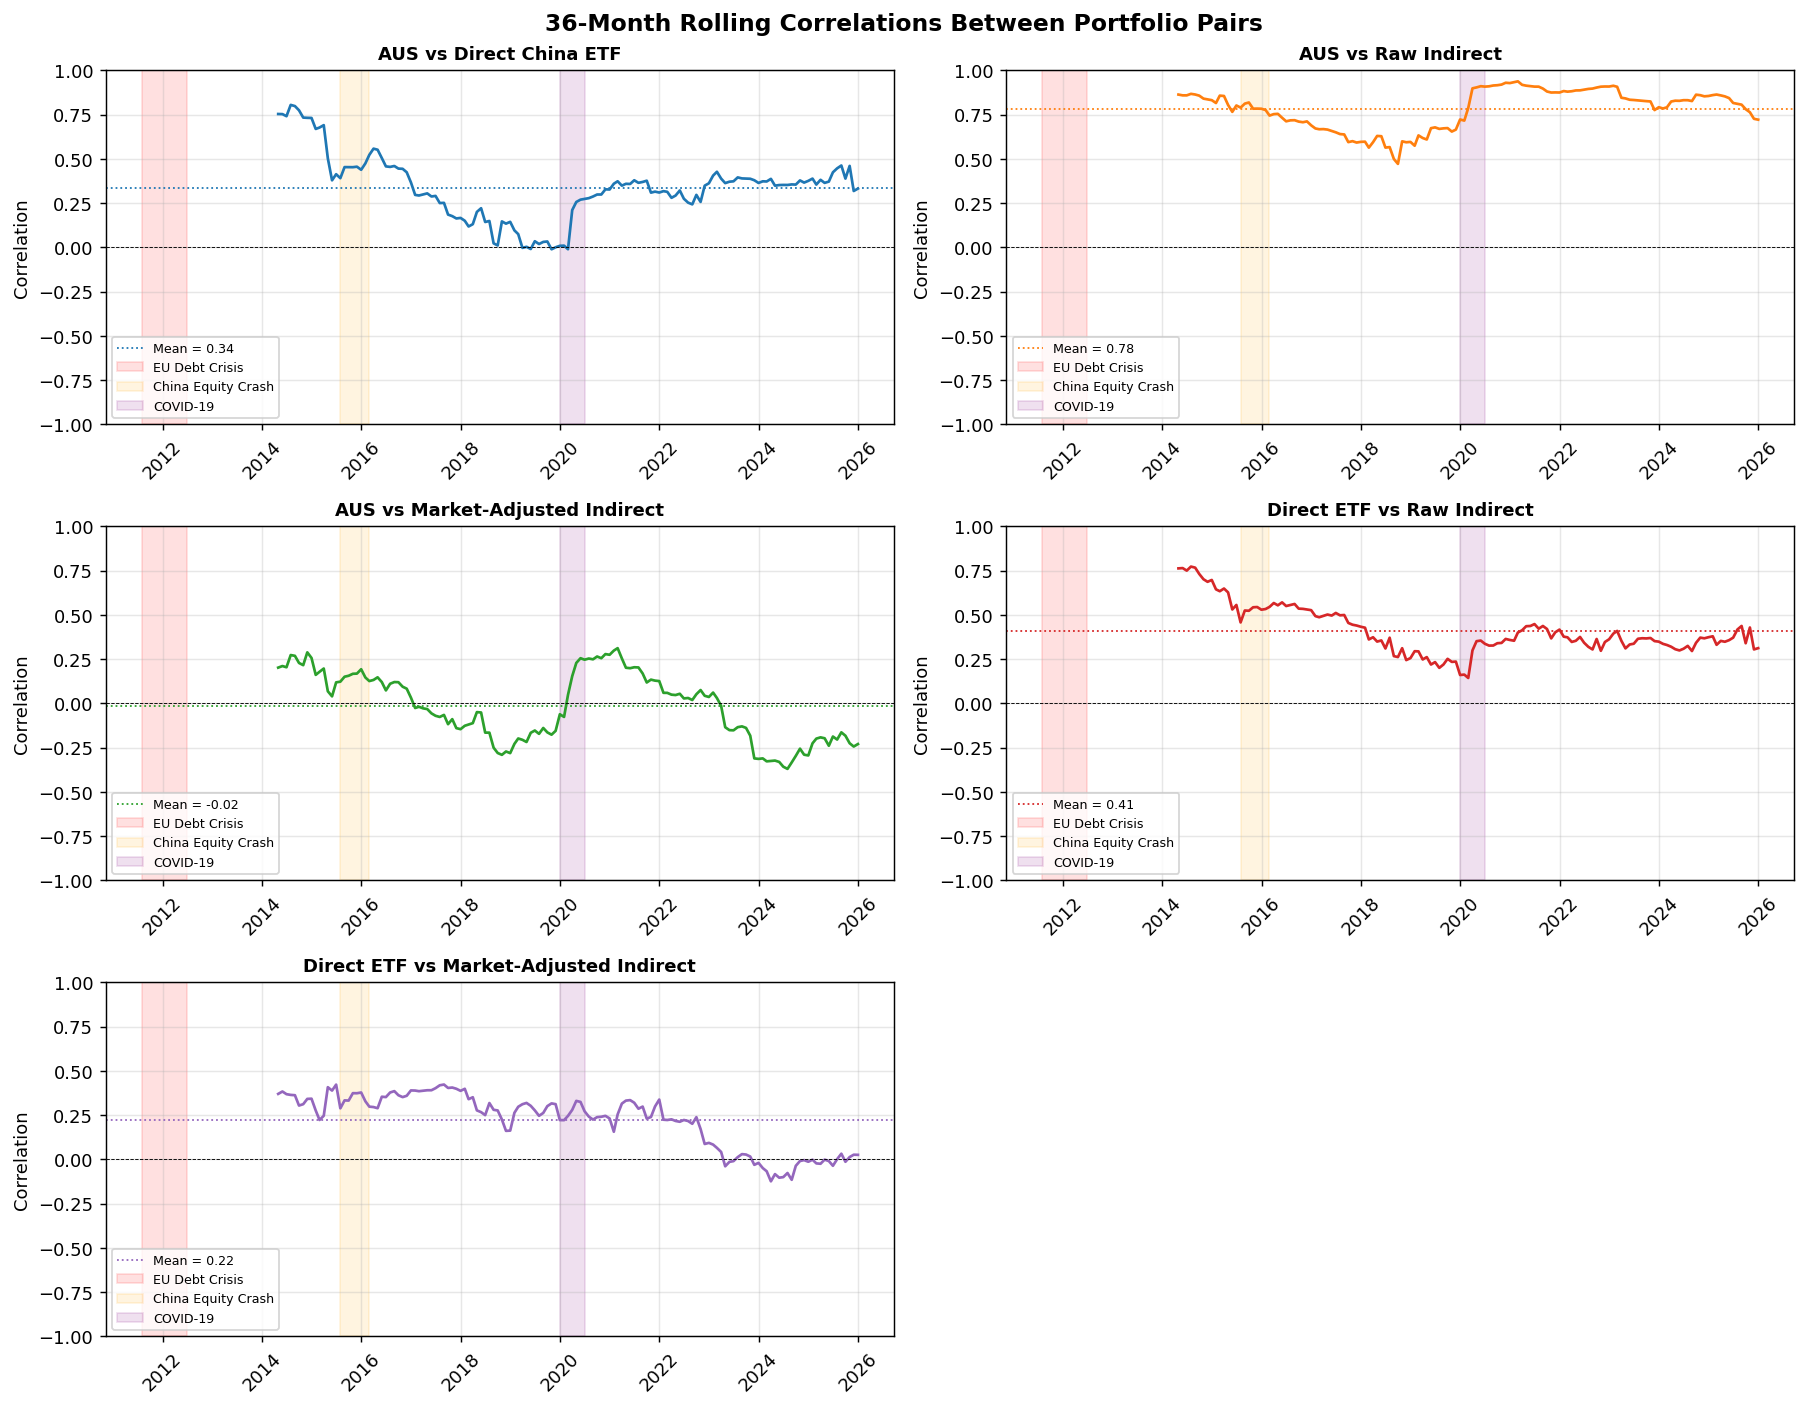

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
axes = axes.flatten()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

crisis_periods = [
    ("2011-08-01", "2012-06-30", "red",    "EU Debt Crisis"),
    ("2015-08-01", "2016-02-28", "orange", "China Equity Crash"),
    ("2020-01-01", "2020-06-30", "purple", "COVID-19"),
]

for i, (_, _, label) in enumerate(pairs):
    ax = axes[i]
    ax.plot(roll_corr.index, roll_corr[label], color=colors[i], linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.axhline(roll_corr[label].mean(), color=colors[i], linewidth=1,
               linestyle=":", label=f"Mean = {roll_corr[label].mean():.2f}")
    for start, end, col, crisis_label in crisis_periods:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color=col, label=crisis_label)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Correlation")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(fontsize=7, loc="lower left")
    ax.set_ylim(-1, 1)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.suptitle("36-Month Rolling Correlations Between Portfolio Pairs",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "rolling_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Risk-Return Statistics (Part E)

In [12]:
def risk_return_stats(series, rf=0.0, label=None):
    s = series.dropna()
    mean_a = s.mean() * 12
    std_a  = s.std()  * np.sqrt(12)
    sharpe = (mean_a - rf) / std_a if std_a > 0 else np.nan
    return {
        "Portfolio":        label or series.name,
        "Ann. Return (%)":  round(mean_a * 100, 2),
        "Ann. Std Dev (%)": round(std_a  * 100, 2),
        "Sharpe Ratio":     round(sharpe, 4),
        "N (months)":       len(s),
    }

port_labels = {
    "R_AUS":        "Australian Market (IOZ.AX)",
    "R_MCHI_AUD":   "Direct China ETF (MCHI, AUD)",
    "R_Indirect":   "Raw Indirect Portfolio",
    "R_Market_Adj": "Market-Adjusted Indirect Portfolio",
}

stats_df = pd.DataFrame([
    risk_return_stats(portfolios[col], rf=RF, label=lbl)
    for col, lbl in port_labels.items()
])
display(stats_df)

,Portfolio,Ann. Return (%),Ann. Std Dev (%),Sharpe Ratio,N (months)
0,Australian Market (IOZ.AX),8.41,13.10,0.6419,176
1,"Direct China ETF (MCHI, AUD)",4.23,31.00,0.1366,176
2,Raw Indirect Portfolio,15.66,16.57,0.9451,176
3,Market-Adjusted Indirect Portfolio,7.11,9.86,0.7212,176


In [13]:
print("Correlation Matrix:")
corr_matrix = portfolios.rename(columns=port_labels).corr().round(4)
display(corr_matrix)

Correlation Matrix:


,Australian Market (IOZ.AX),"Direct China ETF (MCHI, AUD)",Raw Indirect Portfolio,Market-Adjusted Indirect Portfolio
Australian Market (IOZ.AX),1.0000,0.3811,0.8037,-0.0000
"Direct China ETF (MCHI, AUD)",0.3811,1.0000,0.4310,0.2096
Raw Indirect Portfolio,0.8037,0.4310,1.0000,0.5951
Market-Adjusted Indirect Portfolio,-0.0000,0.2096,0.5951,1.0000


## 9. Portfolio Optimisation — w = 0% to 50% (Part F)

In [14]:
weights = np.arange(0, 0.55, 0.05)

strategies = {
    "Pure Australian Market":         None,
    "AUS + Direct China ETF":         "R_MCHI_AUD",
    "AUS + Raw Indirect":             "R_Indirect",
    "AUS + Market-Adjusted Indirect": "R_Market_Adj",
}

all_sweep = {}

for strat_name, overlay_col in strategies.items():
    sweep = []
    for w in weights:
        if overlay_col is None:
            r_port = portfolios["R_AUS"].dropna()
        else:
            combined = pd.concat([portfolios["R_AUS"], portfolios[overlay_col]], axis=1).dropna()
            r_port   = (1 - w) * combined["R_AUS"] + w * combined[overlay_col]

        mean_a = r_port.mean() * 12
        std_a  = r_port.std()  * np.sqrt(12)
        sharpe = (mean_a - RF) / std_a if std_a > 0 else np.nan

        sweep.append({
            "Strategy":        strat_name,
            "Weight w":        round(w, 2),
            "Ann. Return (%)": round(mean_a * 100, 2),
            "Ann. Std (%)":    round(std_a  * 100, 2),
            "Sharpe Ratio":    round(sharpe, 4),
        })

        if overlay_col is None:
            break

    all_sweep[strat_name] = pd.DataFrame(sweep)

display(pd.concat(list(all_sweep.values()), ignore_index=True))

,Strategy,Weight w,Ann. Return (%),Ann. Std (%),Sharpe Ratio
0,Pure Australian Market,0.00,8.41,13.10,0.6419
1,AUS + Direct China ETF,0.00,8.41,13.10,0.6419
2,AUS + Direct China ETF,0.05,8.20,13.11,0.6253
3,AUS + Direct China ETF,0.10,7.99,13.28,0.6016
4,AUS + Direct China ETF,0.15,7.78,13.60,0.5721
5,AUS + Direct China ETF,0.20,7.57,14.06,0.5386
6,AUS + Direct China ETF,0.25,7.36,14.65,0.5028
7,AUS + Direct China ETF,0.30,7.16,15.35,0.4663
8,AUS + Direct China ETF,0.35,6.95,16.14,0.4304
9,AUS + Direct China ETF,0.40,6.74,17.02,0.3959


In [15]:
# Optimal weights
print("Optimal allocations (highest Sharpe Ratio):\n")
opt_rows = []
for strat_name, sweep_df in all_sweep.items():
    best = sweep_df.loc[sweep_df["Sharpe Ratio"].idxmax()]
    opt_rows.append(best)
    print(f"{strat_name}")
    print(f"  Optimal w = {best['Weight w']:.0%}  |  Return = {best['Ann. Return (%)']:.2f}%  "
          f"|  Std = {best['Ann. Std (%)']:.2f}%  |  Sharpe = {best['Sharpe Ratio']:.4f}\n")

Optimal allocations (highest Sharpe Ratio):

Pure Australian Market
  Optimal w = 0%  |  Return = 8.41%  |  Std = 13.10%  |  Sharpe = 0.6419

AUS + Direct China ETF
  Optimal w = 0%  |  Return = 8.41%  |  Std = 13.10%  |  Sharpe = 0.6419

AUS + Raw Indirect
  Optimal w = 50%  |  Return = 12.03%  |  Std = 14.10%  |  Sharpe = 0.8536

AUS + Market-Adjusted Indirect
  Optimal w = 50%  |  Return = 7.76%  |  Std = 8.20%  |  Sharpe = 0.9466



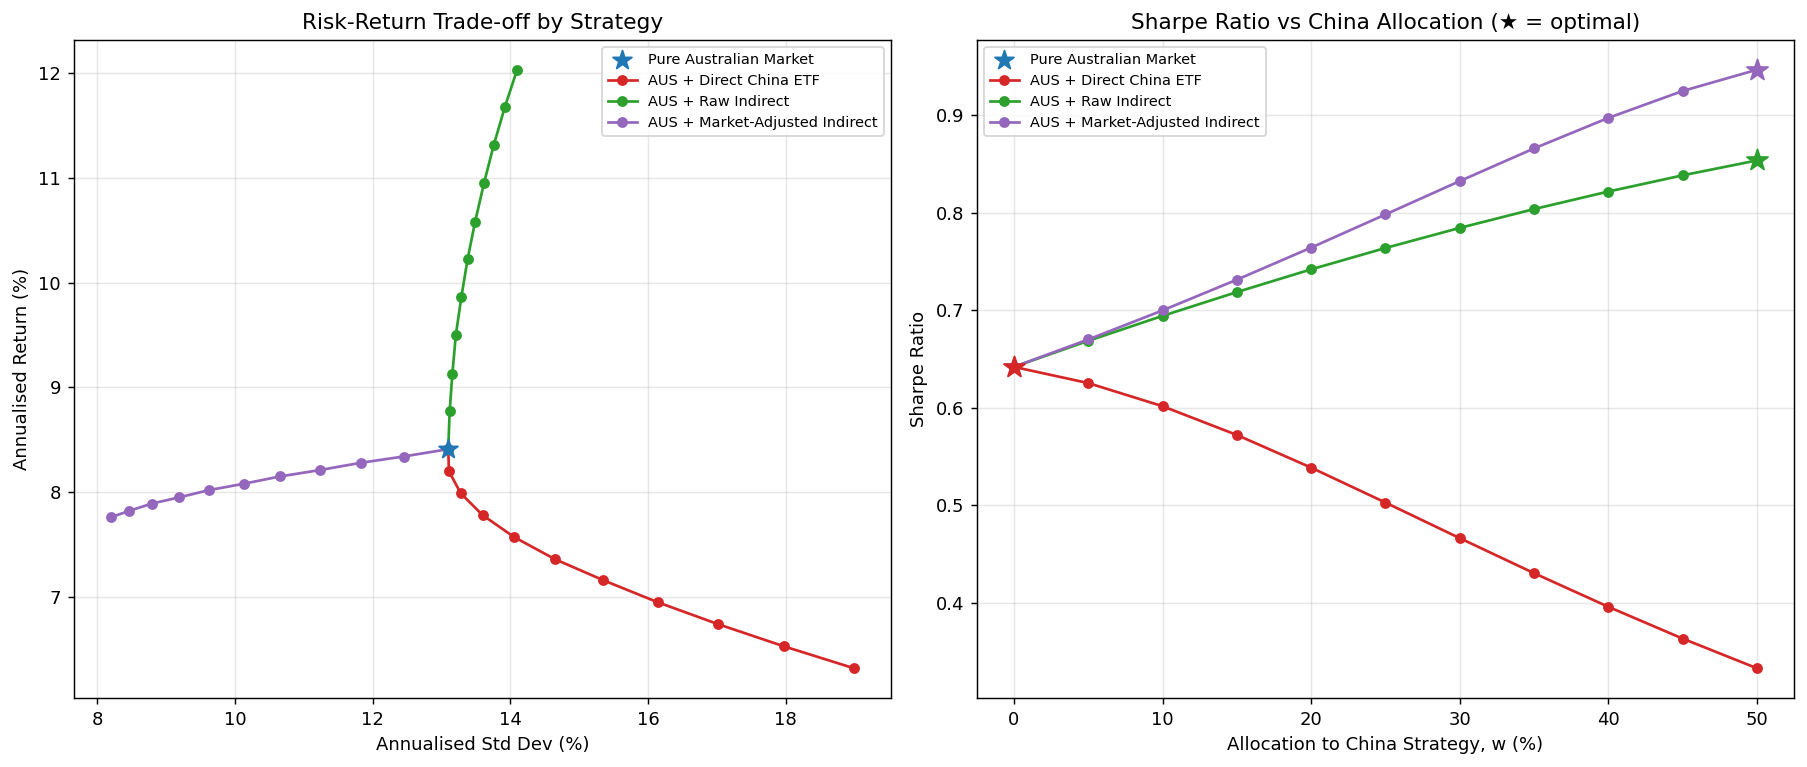

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_strat = {
    "Pure Australian Market":         "#1f77b4",
    "AUS + Direct China ETF":         "#d62728",
    "AUS + Raw Indirect":             "#2ca02c",
    "AUS + Market-Adjusted Indirect": "#9467bd",
}

for strat_name, sweep_df in all_sweep.items():
    c = colors_strat[strat_name]
    if strat_name == "Pure Australian Market":
        axes[0].scatter(sweep_df["Ann. Std (%)"], sweep_df["Ann. Return (%)"],
                        color=c, s=120, zorder=5, label=strat_name, marker="*")
        axes[1].scatter([0], sweep_df["Sharpe Ratio"],
                        color=c, s=120, zorder=5, label=strat_name, marker="*")
    else:
        axes[0].plot(sweep_df["Ann. Std (%)"], sweep_df["Ann. Return (%)"],
                     color=c, marker="o", markersize=5, label=strat_name)
        axes[1].plot(sweep_df["Weight w"] * 100, sweep_df["Sharpe Ratio"],
                     color=c, marker="o", markersize=5, label=strat_name)
        best = sweep_df.loc[sweep_df["Sharpe Ratio"].idxmax()]
        axes[1].scatter(best["Weight w"] * 100, best["Sharpe Ratio"],
                        color=c, s=150, zorder=5, marker="*")

axes[0].set_xlabel("Annualised Std Dev (%)")
axes[0].set_ylabel("Annualised Return (%)")
axes[0].set_title("Risk-Return Trade-off by Strategy")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Allocation to China Strategy, w (%)")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_title("Sharpe Ratio vs China Allocation (★ = optimal)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "portfolio_optimisation.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Export All Results to Excel

In [17]:
with pd.ExcelWriter(OUTPUT_DIR + "FINM3403_Results.xlsx", engine="openpyxl") as writer:

    # Return series
    out_rets = pd.concat([r_aus, r_mchi, r_indirect, r_market_adj,
                          firm_rets, industry_rets], axis=1)
    out_rets.index = out_rets.index.strftime("%Y-%m")
    out_rets.to_excel(writer, sheet_name="Return Series")

    # Market adjustment regression
    pd.DataFrame({
        "Parameter":   ["Alpha", "Beta (IOZ.AX)", "R-squared", "N"],
        "Value":       [round(alpha_mkt, 6), round(beta_mkt, 6),
                        round(mkt_model.rsquared, 4), int(mkt_model.nobs)],
        "t-statistic": [round(mkt_model.tvalues["const"], 3),
                        round(mkt_model.tvalues["R_AUS"], 3), "", ""],
        "p-value":     [round(mkt_model.pvalues["const"], 4),
                        round(mkt_model.pvalues["R_AUS"], 4), "", ""],
    }).to_excel(writer, sheet_name="Market Adj Regression", index=False)

    # China validation
    if nbs_loaded:
        val_df.to_excel(writer, sheet_name="China Validation", index=False)
    else:
        pd.DataFrame({"Note": ["Add nbs_ip.csv and nbs_retail.csv and rerun cell 6"]})             .to_excel(writer, sheet_name="China Validation", index=False)

    # Rolling correlations
    rc_out = roll_corr.copy()
    rc_out.index = rc_out.index.strftime("%Y-%m")
    rc_out.to_excel(writer, sheet_name="Rolling Correlations")

    # Risk-return stats
    stats_df.to_excel(writer, sheet_name="Risk-Return Stats", index=False)
    corr_matrix.to_excel(writer, sheet_name="Risk-Return Stats", startrow=len(stats_df)+3)

    # Optimisation sweep
    pd.concat(list(all_sweep.values()), ignore_index=True)         .to_excel(writer, sheet_name="Portfolio Optimisation", index=False)

print("Saved: FINM3403_Results.xlsx")
print("Saved: rolling_correlations.png")
print("Saved: portfolio_optimisation.png")

Saved: FINM3403_Results.xlsx
Saved: rolling_correlations.png
Saved: portfolio_optimisation.png
